# Create Character-Set Diagrams of the Dreadnoughts 

In [40]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

### Load the Character Sets

In [41]:
import re
from colors_map import *

def loadCharacterSet(charset_lines, ref_offset=0):
    character_set = {}
    charset_data = []
    char_ref = None
    for l in charset_lines:
        if "CHARACTER" in l:
            if charset_data:
                character_set[char_ref] = charset_data
            charset_data = []
            ref = int(l[61:63],16) + ref_offset
            char_ref = f"{ref:0{2}x}".upper()
             
        m = re.findall(r"[0-1]{8}",l)
        if not m:
            continue
        bits = m[0].strip()
        line_bits = []
        for i in range(0,7,2):
            bitpair = bits[i:i+2]
            line_bits += [bitpair]
            line_bits += [bitpair]
        charset_data += [line_bits]
    character_set[char_ref] = charset_data
    return character_set

charsets_file = "uridium/src/charset.asm"
input_file = open(charsets_file,'r')
charset_lines = input_file.readlines()
charset_lines = charset_lines[1439:]
base_character_set = loadCharacterSet(charset_lines)

character_files = [
    "uridium/src/surface1_charset.asm",
    "uridium/src/surface2_charset.asm",
    "uridium/src/surface3_charset.asm",
]
character_sets = []
for filename in character_files:
    charsets_file = filename
    input_file = open(charsets_file,'r')
    charset_lines = input_file.readlines()
    character_set = base_character_set | loadCharacterSet(charset_lines, ref_offset=0x80)
    character_sets += [character_set]


## Generate PNG images of the Character Sets

In [42]:
from PIL import Image, ImageColor
CHARACTER_COLS = 8
CHARACTER_ROWS = 8

def paintRawCharacter(character_set, character, colors, verticalExpand=False):
    multicol0, multicol1,color,color1 = colors
    
    verticalExpansion = 2 if verticalExpand else 1
    CHARACTER_COLS = 8
    CHARACTER_ROWS = 8 * verticalExpansion

    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
        "00": color1,
    }
    
    if character not in character_set:
        print(character)
        return
    
    image_width = CHARACTER_COLS
    image_height = CHARACTER_ROWS
    img = Image.new( 'RGBA', (image_width, image_height))
    pixels = img.load()

    bit_array = character_set[character]
    if verticalExpand:
        expanded_bit_array = []
        for a in bit_array:
            expanded_bit_array += [a,a]
        bit_array = expanded_bit_array
    
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "11":
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            pixels[x,y] = pixel_color
    return img

### Get the Level Specific Color-Schemes and Character Set References

In [43]:
raw_level_color_schemes = """
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_YELLOW,M_ORANGE  ; Level 1
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_LTBLUE,M_BLUE    ; Level 4
        .BYTE M_GREEN,M_LTGREEN,M_ORANGE,M_LTBLUE,M_BLUE  ; Level 5
        .BYTE M_ORANGE,M_YELLOW,M_ORANGE,M_GRAY2,M_BLACK  ; Level 6
        .BYTE M_GRAY1,M_CYAN,M_LTGREEN,M_LTRED,M_RED      ; Level 7
        .BYTE M_BLACK,M_GRAY2,M_LTRED,M_LTBLUE,M_BLUE     ; Level 8
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_GRAY1,M_GRAY2,M_GRAY2,M_LTRED,M_RED       ; Level 10
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_BLUE,M_CYAN,M_ORANGE,M_GRAY2,M_GRAY1      ; Level 12
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_RED,M_LTRED,M_ORANGE,M_YELLOW,M_ORANGE    ; Level 15
"""
raw_level_color_schemes = [l[14:57].split(',') for l in raw_level_color_schemes.split('\n')][1:-1]
raw_level_color_schemes = [[x.strip() for x in l] for l in raw_level_color_schemes]
#raw_level_color_schemes = [v for l in raw_level_color_schemes for v in l]
#surface_ram = [temp_surface_ram[v:v+80] for v in range(0, len(temp_surface_ram), 80)]
#surface_ram = ["$"+x.upper() for x in flatten(surface_ram)]
level_colors = [None]
for l in raw_level_color_schemes:
    colors = (color_constants[l[1]], "c64_black", color_constants[l[0]], "c64_white")
    level_colors += [colors]

# The character sets each level uses.
level_charsets = [0,2,0,2,0,1,2,1,0,1,2,0,2,1,0,2]

level_names = [None, "Zinc","Lead","Copper","Silver","Iron","Gold","Platinum","Tungsten","Iridon","Kallisto","Tri-alloy","Quadmium","Ergonite","Galactium","Uridium"]

In [44]:
level_colors

[None,
 ('c64_gray3', 'c64_black', 'c64_gray1', 'c64_white'),
 ('c64_gray1', 'c64_black', 'c64_black', 'c64_white'),
 ('c64_orange', 'c64_black', 'c64_brown', 'c64_white'),
 ('c64_gray3', 'c64_black', 'c64_gray1', 'c64_white'),
 ('c64_ltgreen', 'c64_black', 'c64_green', 'c64_white'),
 ('c64_yellow', 'c64_black', 'c64_orange', 'c64_white'),
 ('c64_cyan', 'c64_black', 'c64_gray1', 'c64_white'),
 ('c64_lightgray', 'c64_black', 'c64_black', 'c64_white'),
 ('c64_ltblue', 'c64_black', 'c64_blue', 'c64_white'),
 ('c64_lightgray', 'c64_black', 'c64_gray1', 'c64_white'),
 ('c64_orange', 'c64_black', 'c64_brown', 'c64_white'),
 ('c64_cyan', 'c64_black', 'c64_blue', 'c64_white'),
 ('c64_gray1', 'c64_black', 'c64_black', 'c64_white'),
 ('c64_ltblue', 'c64_black', 'c64_blue', 'c64_white'),
 ('c64_ltred', 'c64_black', 'c64_red', 'c64_white')]

### Create PNG Images of the Level-Specific Charactersets

These are character set tiles with the index number in large text

In [45]:
from PIL import ImageDraw, ImageFont
level_character_set_images = [None]
fnt = ImageFont.truetype("RobotoMono-Light.ttf", 90)
for i in range(1,16):
    charset_ref = level_charsets[i]
    colors = level_colors[i]
    character_set = character_sets[charset_ref]
    character_images = {}
    for character_name in character_set:
        img = paintRawCharacter(character_set, character_name, colors)
        img = img.resize((img.width * 15, img.height * 15), Image.NEAREST)
        draw = ImageDraw.Draw(img)
        draw.rectangle((0, 0, img.width, img.height), fill=None, outline="black")
        
        # make a blank image for the text, initialized to transparent text color
        txt = Image.new("RGBA", img.size, (255, 255, 255, 0))
        draw = ImageDraw.Draw(txt)
        draw.text((5, 0), character_name, font=fnt, fill="#FFFFFF00", stroke_width=4, stroke_fill='black')
        img = Image.alpha_composite(img, txt)
    
        character_images["$"+character_name] = img
        if character_name:
            img.save(f"surface_character_set_diagrams/character_sets/{i}_{character_name}.png")
    level_character_set_images += [character_images]

### Create PNG Diagrams of the Level-Specific Charactersets

In [46]:
from PIL import Image, ImageColor
CHARACTER_COLS = 8
CHARACTER_ROWS = 8
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintCharacterDiagram(character_set, character, colors, verticalExpand=False):
    multicol0, multicol1,color,color1 = colors
    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
        "00": color1,
    }
    
    image_width = CELL_WIDTH*CHARACTER_COLS
    image_height = CELL_HEIGHT*CHARACTER_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    draw = ImageDraw.Draw(img)

    fnt = ImageFont.truetype("RobotoMono-Light.ttf", 40)
    bit_array = character_set[character]
    # Remember that each bitpair in the bit_array is duplicated.
    # e.g. 01 appears as 01,01 so that we can treat each element as
    # a single bit.
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            color_name = colormap[bit]
            pixel_color = ImageColor.getrgb(c64_to_rgb[color_name])
            X = x * CELL_WIDTH
            Y = y * CELL_HEIGHT
            draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), 
                           fill=pixel_color, outline="black")
            b = bit[(x%2)] # Get the correct side of the bitpair
            text_color = "black" if color_name in ["c64_white","c64_yellow","c64_cyan"] else "white"
            draw.text((X+10, Y-8), b, font=fnt, fill=text_color)
    return img


In [47]:
from PIL import ImageDraw, ImageFont
level_character_set_diagrams = [None]
for i in range(1,16):
    charset_ref = level_charsets[i]
    colors = level_colors[i]
    character_set = character_sets[charset_ref]
    diagram_character_images = {}
    for character_name in character_set:
        img = paintCharacterDiagram(character_set, character_name, colors)
        diagram_character_images["$"+character_name] = img
        if character_name:
            img.save(f"surface_character_set_diagrams/character_set_diagrams/{i}_{character_name}.png")
    level_character_set_diagrams += [diagram_character_images]

In [48]:
byte_literals = """.BYTE
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
"""

def generateCharacterDiagram(character_image, character_name, level_name, level, colors, character_bytes):

    img = Image.new('RGBA', (540,350))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"{level_name.upper()}/CHAR/{character_name}"
    label_fnt_size = 19
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (5, (img.height - (label.height + 20))))

    # Color Label
    label_text = "BASE_COLOR: "
    label_fnt_size = 15
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * (label_fnt_size)
    txt = Image.new('RGBA', (txt_width-10, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[2]])
    draw.rectangle([(110,4), (120,14)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (30,330))

    # MultiCol0 Label
    label_text = "MULTI_COLOR0: "
    label_fnt_size = 15
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[1]])
    draw.rectangle([(130,4), (140,14)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (190,330))

    # MultiCol1 Label
    label_text = "MULTI_COLOR1: "
    label_fnt_size = 15
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[3]])
    draw.rectangle([(130,4), (140,14)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (370,330))


    # Sprite byte literals
    label_text = byte_literals
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(character_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (350,8))

    # Sprite bytes
    label_text = character_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(character_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (470,8))
    
    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)
    img.paste(character_image, (30,10))

    return img

def convertCharBitmapToByte(bits):
    bits = bits[::2] # every second element in the list
    bit_string = ''.join(bits)
    byte = ("00" + hex(int(bit_string,2))[2:])[-2:].upper()
    return byte


In [49]:
from PIL import ImageDraw, ImageFont

    
for level in range(1,16):
    charset_ref = level_charsets[level]
    character_set = character_sets[charset_ref]
    
    level_name = level_names[level]
    charset_ref = level_charsets[level]
    colors = level_colors[level]

    character_set_diagrams_for_level = level_character_set_diagrams[level]
    for character_name in character_set:
        character_image = character_set_diagrams_for_level["$"+character_name]
        character_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in character_set[character_name]])
        img = generateCharacterDiagram(character_image, character_name, level_name, level, colors, character_bytes)
        img.save(f"surface_character_set_diagrams/character_set_diagrams/{level}_{character_name}.png")


## Read in the Surface Structures Data (surfaceStructureData)

In [50]:
"""
Entries in this array have the structure, e.g.:

.BYTE $01  ; Number of Elements
.BYTE $01  ; Run-Length of element
.BYTE $20  ; Data (List of Character Set references)

"""
game_data_file = "uridium/src/game_data.asm"
lines_in_file = open(game_data_file,'r').readlines()

structure_data_header = lines_in_file[770]
assert ("surfaceStructureData" in structure_data_header)
structure_data_lines = lines_in_file[771:1230]

raw_surface_structure_data = [l[14:].strip() for l in structure_data_lines]
surface_structure_data = [x for l in raw_surface_structure_data for x in l.split(',')]

In [51]:
toInt = lambda x: int(x[1:],16)
surface_structures = []
i = 0
while (i < len(surface_structure_data)):
    num_elements = toInt(surface_structure_data[i])
    i += 1
    structure_data = []
    for j in range(0,num_elements):
        run_length = toInt(surface_structure_data[i])
        i += 1
        run_length = run_length & 0x1F
        raw_data = surface_structure_data[i:i+run_length]
        i += run_length
        data = [x[1:] for x in raw_data]
        structure_data += [data]
    surface_structures += [structure_data]

#for i,s in enumerate(surface_structures):
#    print(hex(i),s)

### Generate PNG Images of all the Structures

There are two kinds - images for the surface and images for structures placed on the surface. We pad out the surface images with spaces.

In [52]:
# First we do the surface images, padded with spaces at the top.
SURFACE_ROWS = 17
character_height = level_character_set_images[1]["$00"].height
character_width = level_character_set_images[1]["$00"].width
for j in range(1,16):
    character_images = level_character_set_images[j]
    for i,surface_structure in enumerate(surface_structures):
        if not surface_structure:
            continue
        HEIGHT = character_height * SURFACE_ROWS
        WIDTH = len(surface_structure) * character_width
        x,y = 0,HEIGHT-character_height
        img = Image.new( 'RGBA', (WIDTH,HEIGHT))
        for strip in surface_structure:
            for k,c in enumerate(strip):
                char_image = character_images["$"+c]
                img.paste(char_image,(x,y),mask=char_image)
                y-=character_height
            # pad with spaces
            char_image = character_images["$20"]
            while k <= SURFACE_ROWS:
                img.paste(char_image,(x,y),mask=char_image)
                y-=character_height
                k+=1
            x+=character_width
            y=HEIGHT-character_height
        ref_offset = i+1
        ref = ("00" + hex(ref_offset)[2:].upper())[-2:]

        #img = img.resize((img.width * 5, img.height * 5), Image.NEAREST)
        img.save(f"surface_character_set_diagrams/surface_strips/{j}_{i}.png")
        img.save(f"surface_character_set_diagrams/surface_strips_hex/{j}_{ref}.png")

In [53]:
# Next we do the same images, but without any padding spaces.
character_height = level_character_set_images[1]["$00"].height
character_width = level_character_set_images[1]["$00"].width
for j in range(1,16):
    character_images = level_character_set_images[j]
    for i,surface_structure in enumerate(surface_structures):
        if not surface_structure:
            continue
        strip_max = max([len(x) for x in surface_structure])
        HEIGHT = character_height * strip_max
        WIDTH = len(surface_structure) * character_width
        x,y = 0,HEIGHT-character_height
        img = Image.new( 'RGBA', (WIDTH,HEIGHT))
        for strip in surface_structure:
            for c in strip:
                if c == "20":
                    y-=character_height
                    continue
                char_image = character_images["$"+c]
                img.paste(char_image,(x,y),mask=char_image)
                y-=character_height
            x+=character_width
            y=HEIGHT-character_height
        ref_offset = i+1
        ref = ("00" + hex(ref_offset)[2:].upper())[-2:]

        #img = img.resize((img.width * 5, img.height * 5), Image.NEAREST)
        img.save(f"surface_character_set_diagrams/surface_structures/{j}_{i}.png")
        img.save(f"surface_character_set_diagrams/surface_structures_hex/{j}_{ref}.png")        

### Read in the Dreadnought Data for All Levels

In [54]:
def getDreadnoughtData(level_data_lines):
    raw_dreadnought_data = [l[14:].strip() for l in level_data_lines]
    dreadnought_data = [x for l in raw_dreadnought_data for x in l.split(',')]

    end_of_base_data = dreadnought_data.index('$00')
    base_data = [x[1:] for x in dreadnought_data[:end_of_base_data]]
    raw_location_data = dreadnought_data[end_of_base_data+1:]
    location_data = []
    for i in range(0, len(raw_location_data), 3):
        hi_byte = int(raw_location_data[i][1:],16)
        if not hi_byte:
            break
        hi_byte |= 0x80
        hi_byte &= 0xBF
        hi_byte = hex(hi_byte)[2:]
        lo_byte = raw_location_data[i+1][1:]
        hex_location = hi_byte + lo_byte
        location = int(hex_location,16)
        structure = raw_location_data[i+2][1:]
        location_data += [(hex_location, location,structure)]
    dreadnought_surface = (base_data,location_data)
    return dreadnought_surface

# Read in bulk of the dreadnought data from level data first.
level_data_file = "uridium/src/level_data.asm"
lines_in_file = open(level_data_file,'r').readlines()

dreadnought_surfaces = {}
level_data_lines = []
current_dreadnought = ""
for l in lines_in_file:
    if l.startswith("level") and "DreadnoughtData" in l:
        if current_dreadnought:
            dreadnought_surfaces[current_dreadnought] = getDreadnoughtData(level_data_lines)
        current_dreadnought = l[:22].strip()
        level_data_lines = []
    if ".BYTE" not in l:
        continue
    level_data_lines += [l]
dreadnought_surfaces[current_dreadnought] = getDreadnoughtData(level_data_lines)

# Read in remaining dreadnoughts from charset.asm
level_data_file = "uridium/src/charset.asm"
lines_in_file = open(level_data_file,'r').readlines()

assert "level7DreadnoughtData" in lines_in_file[1297]
level_data_lines = [l for l in lines_in_file[1298:1358] if ".BYTE" in l]
dreadnought_surfaces["level7DreadnoughtData"] = getDreadnoughtData(level_data_lines)

assert "level8DreadnoughtData" in lines_in_file[1358]
level_data_lines = [l for l in lines_in_file[1359:1425] if ".BYTE" in l]
dreadnought_surfaces["level8DreadnoughtData"] = getDreadnoughtData(level_data_lines)


### Render the Dreadnought Charset Diagrams for All Level

In [55]:
import math

LOCATION_START = 0x8200
LOCATION_END = 0xA400
DREADNOUGHT_COLS = 0x200

character_height = level_character_set_images[1]["$00"].height
character_width = level_character_set_images[1]["$00"].width

width = DREADNOUGHT_COLS * character_width # 4096
height = int((LOCATION_END - LOCATION_START) / DREADNOUGHT_COLS) * character_height # 128

for LEVEL in range(1,16):
    img = Image.new( 'RGBA', (width,height))
    base_data, location_data = dreadnought_surfaces[f"level{LEVEL}DreadnoughtData"]

    x,y = (64 * character_width),0
    for structure in base_data:
        strip_image = Image.open(f"surface_character_set_diagrams/surface_strips_hex/{LEVEL}_{structure}.png")
        # Y position is relative to the bottom of the map.
        y = height - strip_image.height
        img.paste(strip_image,(x,y),mask=strip_image)
        x+= strip_image.width

    for hex_offset, location, structure in location_data:
        if structure == "20":
            print(structure)
        strip_image = Image.open(f"surface_character_set_diagrams/surface_structures_hex/{LEVEL}_{structure}.png")
        offset = location - LOCATION_START
        x = (offset % DREADNOUGHT_COLS) * character_width
        # The location given is for the bottom of the object (uridium draws upwards)
        y = (int(math.ceil(offset / DREADNOUGHT_COLS)) * character_height) - strip_image.height
        img.paste(strip_image,(x,y),mask=strip_image)
    img.save(f"surface_character_set_diagrams/surface_diagrams/{LEVEL}.png")


In [71]:
def generateSectionDiagram(section_image, section_name, level_name, level_number):

    image_width = 150 + section_image.width + 10
    image_height = 10 + section_image.height + 10
    img = Image.new('RGBA', (image_width,image_height))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"URIDIUM/{('00'+str(level_number))[-2:]}/{level_name.upper()}/{section_name.upper()}"
    label_fnt_size = 80
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (10, (img.height - (label.height + 20))))

    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)
    img.paste(section_image, (100,10))

    return img

### Draw a Section from Level 6

In [57]:
from PIL import Image
TILE_WIDTH = 120
SECTION_START = 77
SECTION_WIDTH = 26
section_start = SECTION_START * TILE_WIDTH
section_end = (SECTION_START * TILE_WIDTH) + (SECTION_WIDTH * TILE_WIDTH)

level = 6
level_name = level_names[level]
section_name = "BOW"

img = Image.open(f"surface_character_set_diagrams/surface_diagrams/{level}.png")
section_image = img.crop((section_start,0,section_end,img.height))

diagram_image = generateSectionDiagram(section_image, section_name, level_name, level)
diagram_image.save(f"surface_character_set_diagrams/section_diagrams/{level}_{section_name}.png")


### Draw a Section from Level 5

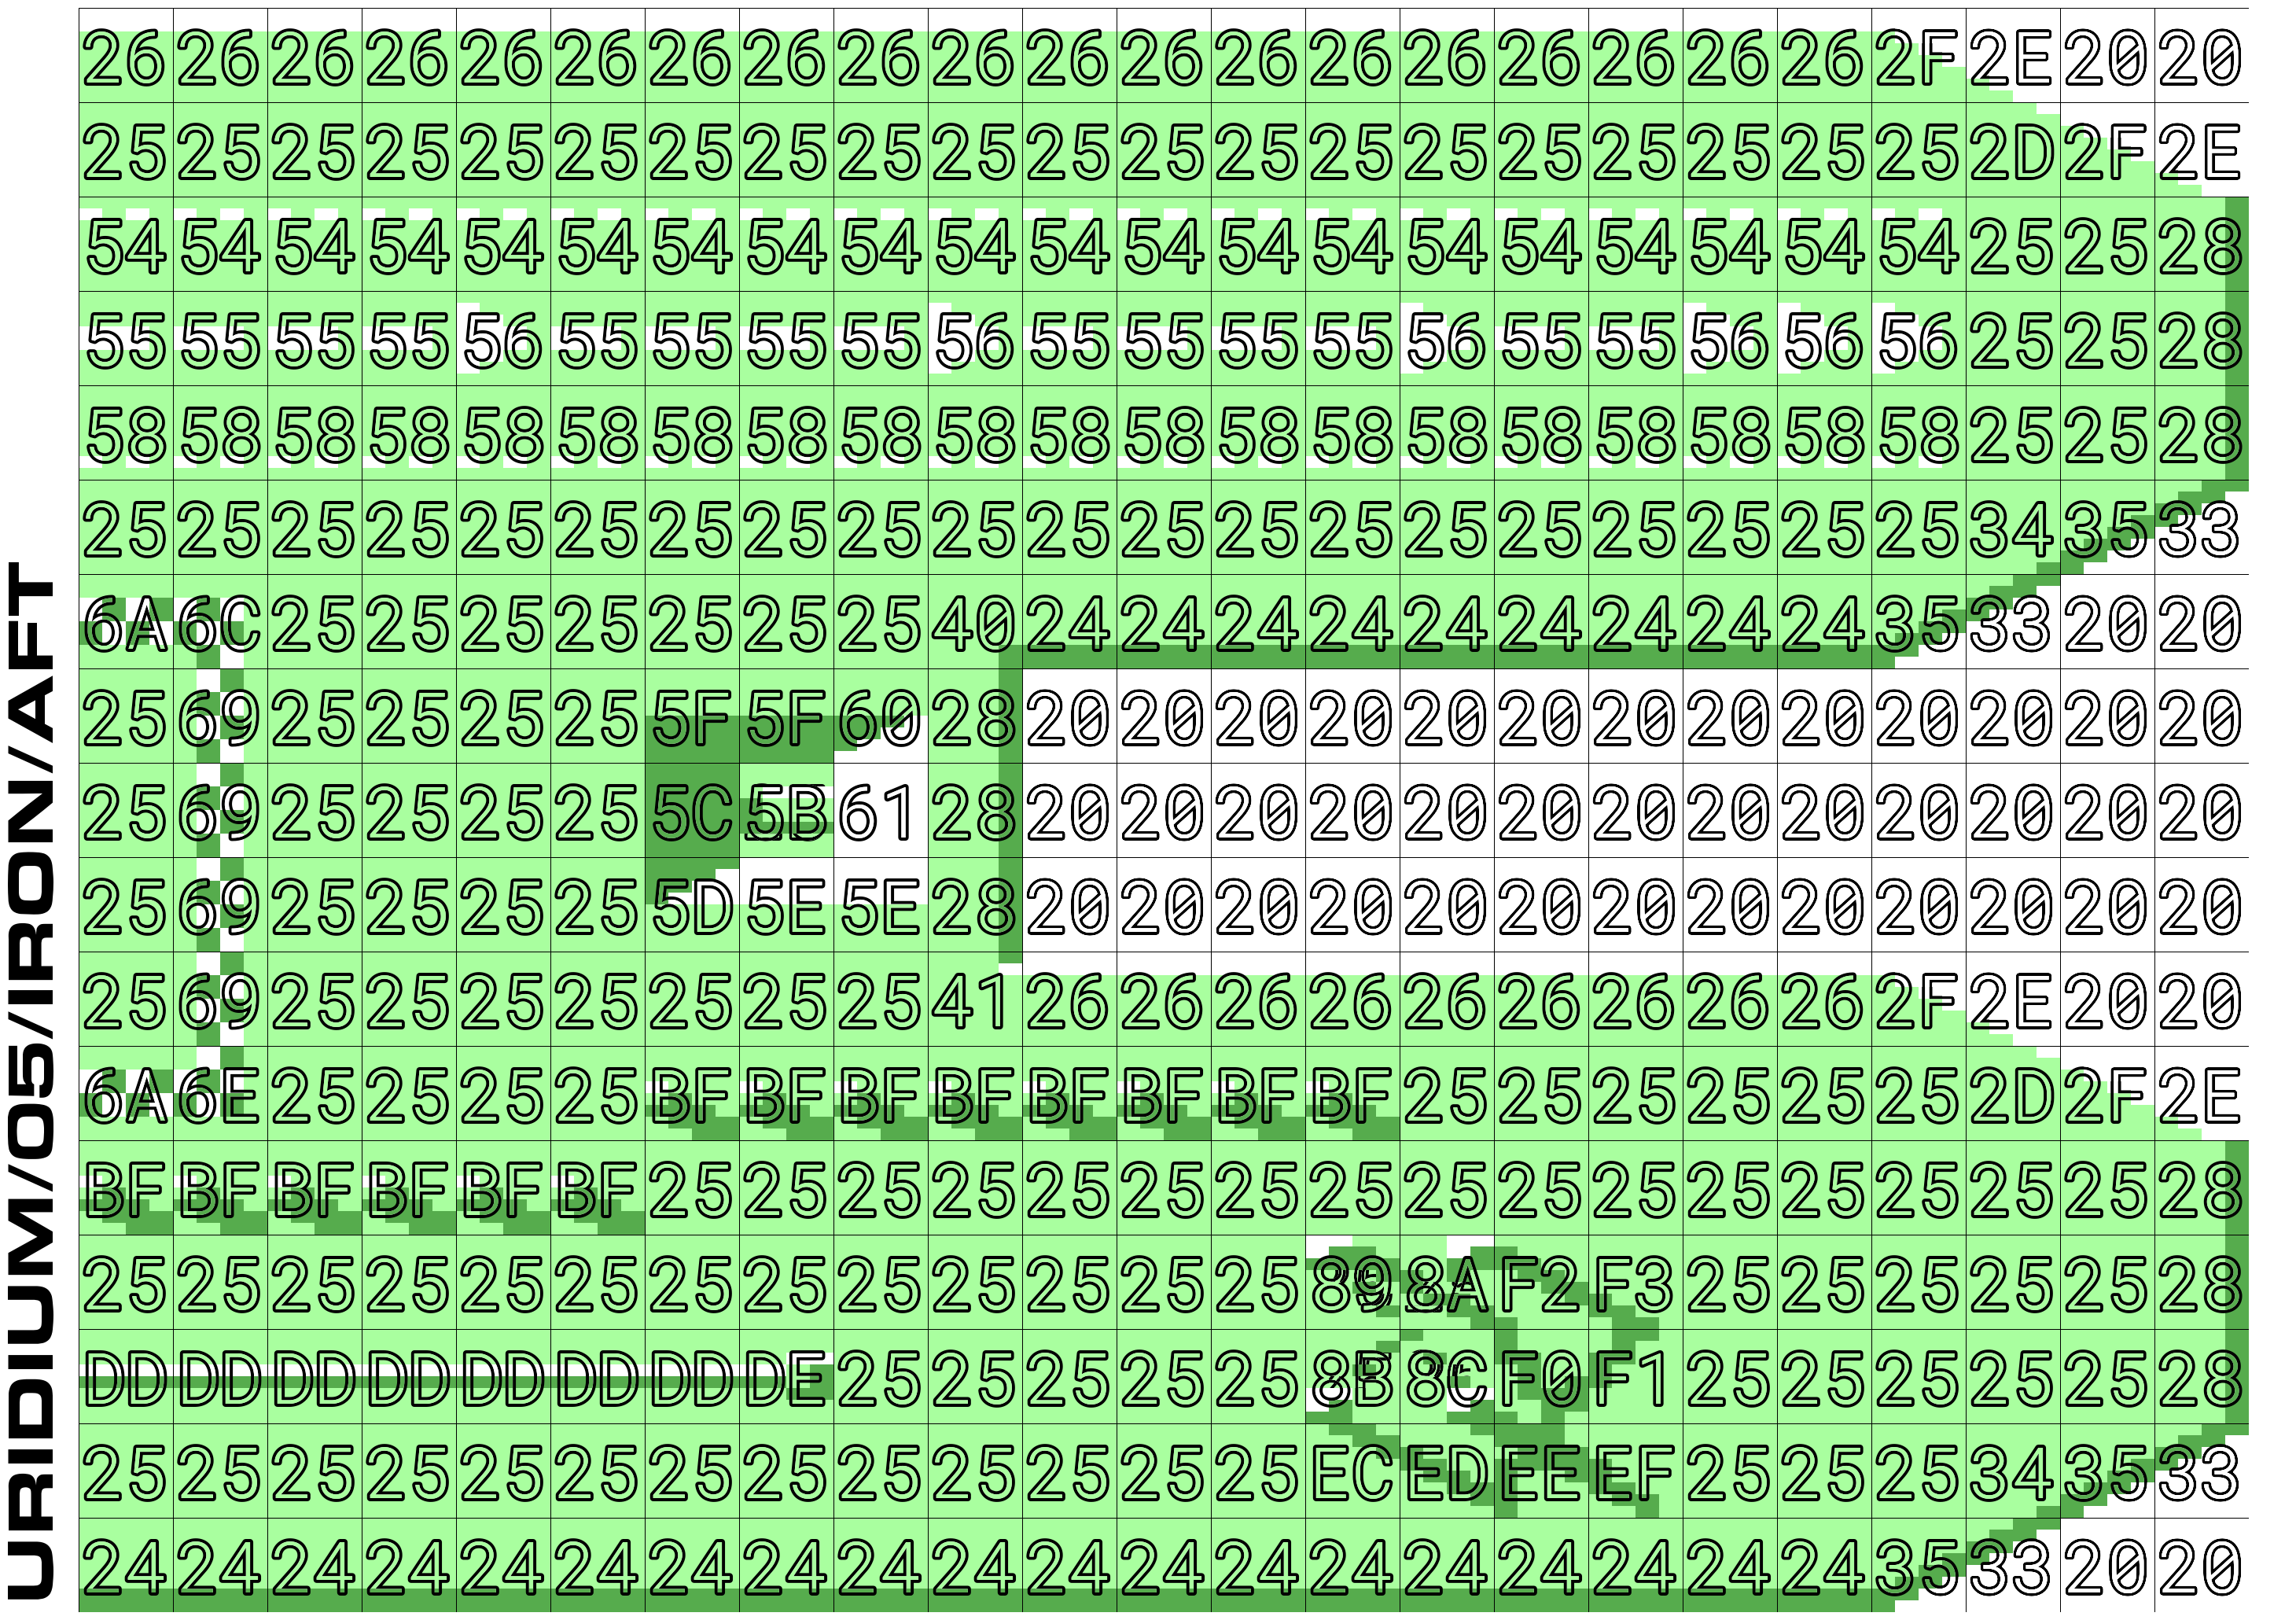

In [58]:
from PIL import Image
TILE_WIDTH = 120
SECTION_START = 425
SECTION_WIDTH = 23
section_start = SECTION_START * TILE_WIDTH
section_end = (SECTION_START * TILE_WIDTH) + (SECTION_WIDTH * TILE_WIDTH)

level = 5
level_name = level_names[level]
section_name = "AFT"

img = Image.open(f"surface_character_set_diagrams/surface_diagrams/{level}.png")
section_image = img.crop((section_start,0,section_end,img.height))

diagram_image = generateSectionDiagram(section_image, section_name, level_name, level)
diagram_image.save(f"surface_character_set_diagrams/section_diagrams/{level}_{section_name}.png")
diagram_image

In [95]:
def generateMiniCharDiagram(char_img, char_name):
    image_width = 10 + char_img.width + 10
    image_height = 10 + char_img.height + 70
    img = Image.new('RGBA', (image_width,image_height))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"{char_name.upper()}"
    label_fnt_size = 70
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    draw = ImageDraw.Draw(img)
    draw.text((10, char_img.height + 20), label_text, font=label_fnt, fill="black")

    img.paste(char_img, (18,10), mask=char_img)

    return img

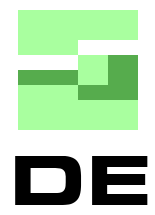

In [104]:
chars = ["24","25","26","55","56","58","BF","DD","5B","5C","5D","5E","60","61","33","34","34","2D","2E","2F","DE"]
level = 5
for char in chars:
    char_img = Image.open(f"surface_characters/{level}_{char}.png")
    img = generateMiniCharDiagram(char_img, char)
    img.save(f"surface_character_set_diagrams/surface_character_mini_diagrams/{level}_{char}.png")
img

In [105]:
!cp -R surface_character_set_diagrams/surface_character_mini_diagrams ../src/

### Draw a front section from level 5

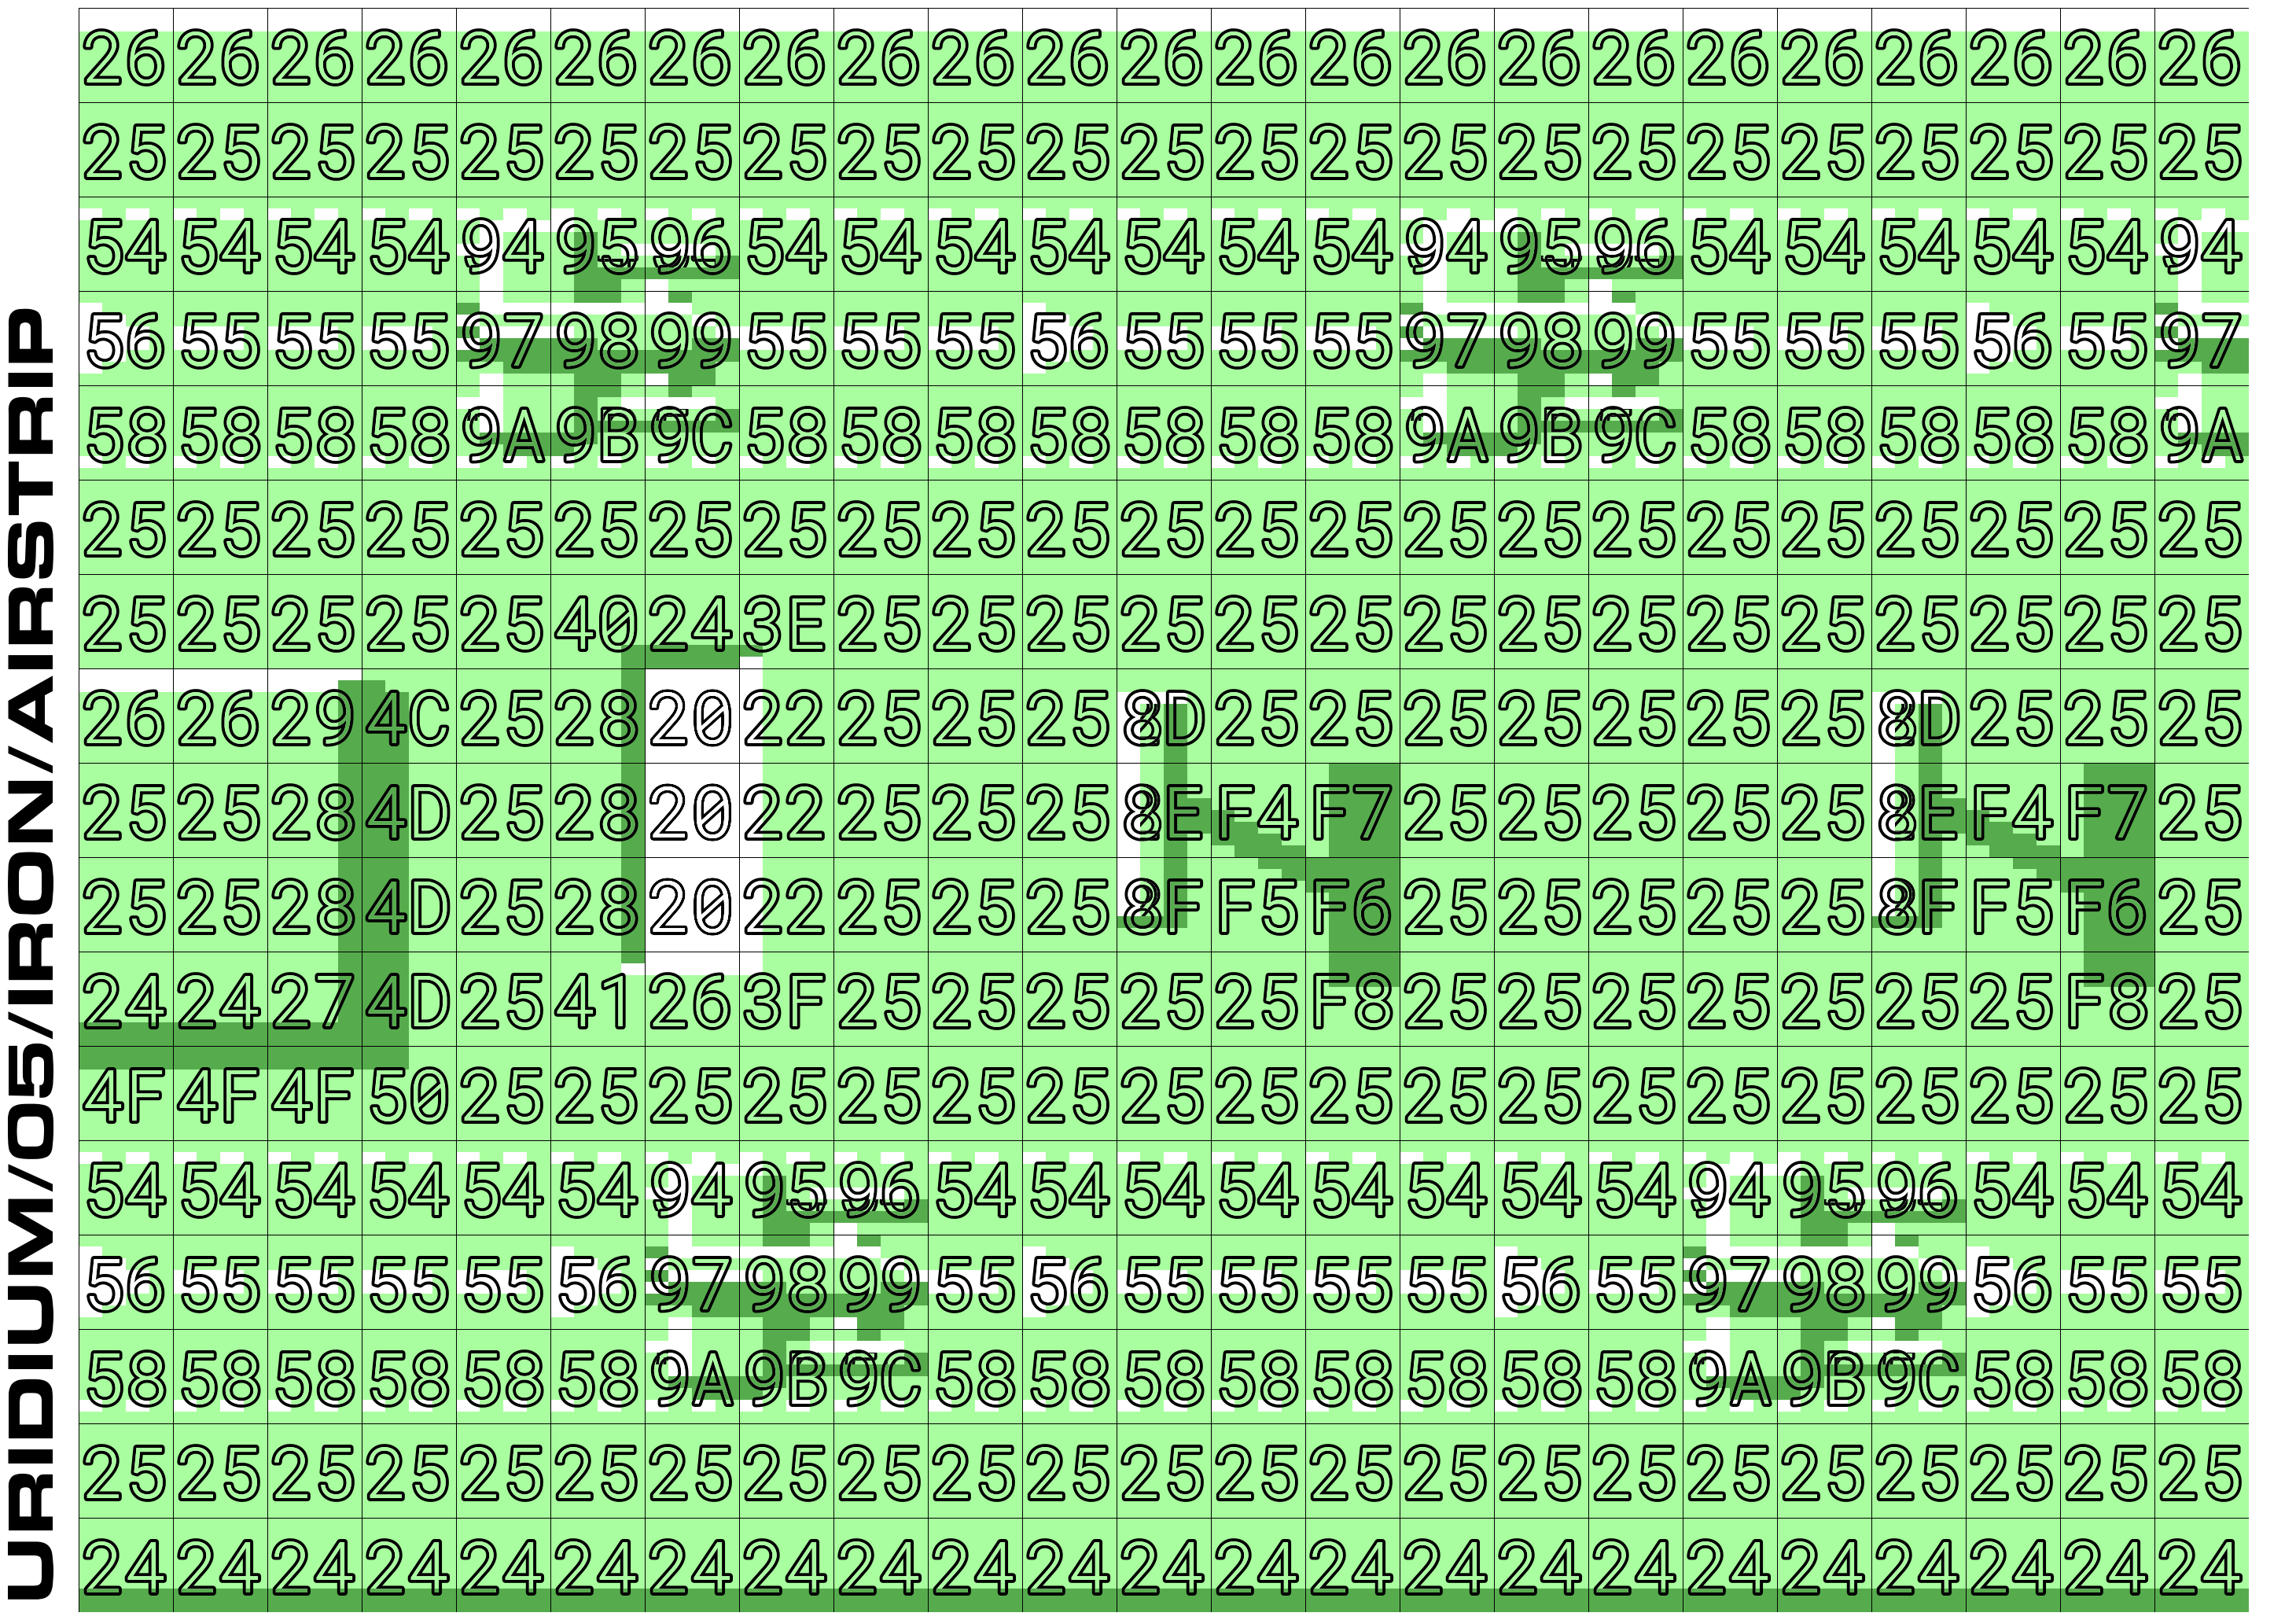

In [109]:
from PIL import Image
TILE_WIDTH = 120
SECTION_START = 145
SECTION_WIDTH = 23
section_start = SECTION_START * TILE_WIDTH
section_end = (SECTION_START * TILE_WIDTH) + (SECTION_WIDTH * TILE_WIDTH)

level = 5
level_name = level_names[level]
section_name = "AIRSTRIP"

img = Image.open(f"surface_character_set_diagrams/surface_diagrams/{level}.png")
section_image = img.crop((section_start,0,section_end,img.height))

diagram_image = generateSectionDiagram(section_image, section_name, level_name, level)
diagram_image.save(f"surface_character_set_diagrams/section_diagrams/{level}_{section_name}.png")
diagram_image

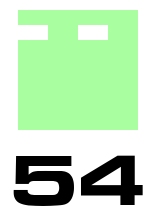

In [113]:
chars = ["24","25","26","27","28","29","8D","8E","8F","94","95","96","97","98","99","9A","9B","9C","8D","8E","8F","F4","F4","F5","F6","F7","F8","54"]
level = 5
for char in chars:
    char_img = Image.open(f"surface_characters/{level}_{char}.png")
    img = generateMiniCharDiagram(char_img, char)
    img.save(f"surface_character_set_diagrams/surface_character_mini_diagrams/{level}_{char}.png")
img

In [136]:
img = Image.open(f"surface_diagrams/5_horizontal_1.png")
draw = ImageDraw.Draw(img)
clip_start = int(section_start / 13.1)
clip_end = int(section_end / 12)
draw.rectangle([(clip_start,70),(clip_end,img.height-1)], fill=None, outline="black", width=2)
img.save(f"surface_diagrams/5_horizontal_1_highlight.png")

In [114]:
!cp -R surface_character_set_diagrams/surface_character_mini_diagrams ../src/

# Scratchpad